# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [1]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [32]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()


**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | mismatched column name style | .columns | all | replaced | to keep all column names consistant |
| 2 | number_of_doors is a float | .dtypes | all | replaced | integer is more logical to assume the number of doors |
| 3 | 'engine_cylinders' are na for electric cars | .isna().sum() | 30 | replaced | these rows are electric cars, they don't have cylinders/ 0 cylinders |
| 4 | duplicates | .duplicated().sum() | 720 | drop it | they're already counted. there is no purpose to have duplicates here |
| 5 | max 'highway_mpg' is a outlier and not electric | .describe() | 1 | replaced | it was probably a decimal dot typo. looking at another Audi A6 it has the same value if the decimal was to the left |
| 7 | unsure msrp are set to 2000 | ['msrp'].value_counts() | 747 | set to NaN | it's better to be unsure then set a innacturate value |

In [2]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names
clean.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'vehicle_size', 'vehicle_style', 'highway_mpg',
       'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [3]:
clean['number_of_doors'] = clean['number_of_doors'].astype('Int64')
clean['number_of_doors'].value_counts()


number_of_doors
4    8353
2    3160
3     395
Name: count, dtype: Int64

In [4]:
clean['engine_cylinders'] = clean['engine_cylinders'].fillna(0)
clean['engine_cylinders'].isna().sum()

np.int64(0)

In [5]:
clean = clean.drop_duplicates()
clean.duplicated().sum()

np.int64(0)

In [6]:
clean['highway_mpg'] = clean['highway_mpg'].replace(354, 354/10)
clean.describe()

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,msrp
count,11194.000000,11125.000000,11194.000000,11188.0,11194.000000,11194.000000,11194.000000,1.119400e+04
mean,2010.715026,253.390562,5.650616,3.454058,26.581776,19.732089,1557.964445,4.193329e+04
std,7.226875,110.170627,1.818548,0.872972,8.429487,9.179458,1445.449268,6.154731e+04
min,1990.000000,55.000000,0.000000,2.0,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,172.000000,4.000000,2.0,22.000000,16.000000,549.000000,2.159925e+04
50%,2015.000000,239.000000,6.000000,4.0,25.000000,18.000000,1385.000000,3.067500e+04
75%,2016.000000,303.000000,6.000000,4.0,30.000000,22.000000,2009.000000,4.303875e+04
max,2017.000000,1001.000000,16.000000,4.0,111.000000,137.000000,5657.000000,2.065902e+06


In [7]:
clean['msrp'] = clean['msrp'].replace(2000, np.nan)
clean['msrp'].value_counts()

msrp
29995.0    18
25995.0    17
20995.0    15
27995.0    15
24995.0    14
           ..
56570.0     1
50520.0     1
46120.0     1
50620.0     1
50920.0     1
Name: count, Length: 6048, dtype: int64

In [8]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 15)
engine_fuel_type      3
engine_hp            69
number_of_doors       6
msrp                747
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

mean = 44788.66689001627    media = 31870.0
The mean is bigger because its influenced by outliers. For example, million dollar supercars.


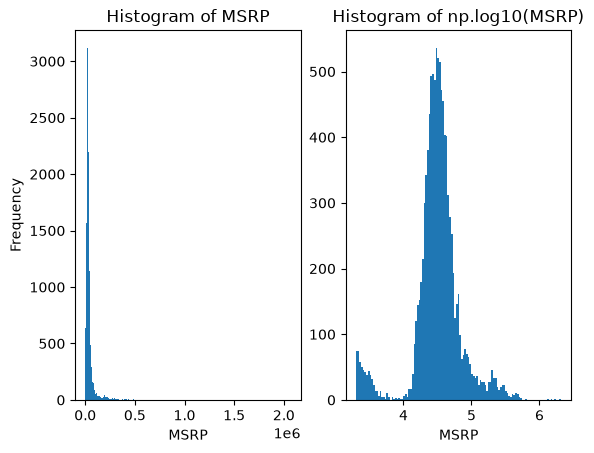

percentage of cars that cost more than the mean: 22.815794175451135


In [9]:
# a) mean and median
msrp_mean = clean['msrp'].mean()
msrp_median = clean['msrp'].median()
print(f"mean = {msrp_mean}    media = {msrp_median}")
print("The mean is bigger because its influenced by outliers. For example, million dollar supercars.")
# b) two histograms side by side (plt.subplots(1, 2))
fig, axs = plt.subplots(1,2)
axs[0].hist(clean['msrp'], bins='auto')
axs[0].set_title('Histogram of MSRP')
axs[0].set_xlabel('MSRP')
axs[0].set_ylabel('Frequency')

axs[1].hist(np.log10(clean['msrp']), bins='auto')
axs[1].set_title('Histogram of np.log10(MSRP)')
axs[1].set_xlabel('MSRP')

plt.show()
# c) share of cars above the mean
aboveMean = len(clean[clean['msrp'] >= msrp_mean])/len(clean['msrp']) * 100
print(f"percentage of cars that cost more than the mean: {aboveMean}")

**Answer:**
the median belongs on the hompage because its a more accurate representation of the typical cost of a car. medians are less influenced by outliers and sways in the data.

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [10]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
cars_2017 = clean[clean['year'] == 2017]
print(cars_2017.groupby('vehicle_size')['highway_mpg'].agg(['mean', 'std']))
# b) z = (value - class mean) / class std
print(f"\nHonda Civic z-score: {(42 - 31.994197) / 10.784983}")
print(f"Volvo S90 z-score: {(34 - 22.991453) / 3.491184}")


                   mean        std
vehicle_size                      
Compact       31.994197  10.784983
Large         22.991453   3.491184
Midsize       29.420031   5.453167

Honda Civic z-score: 0.9277532472698381
Volvo S90 z-score: 3.1532417082571413


**Answer:**
Based on the z-scores, the Volvo S90 is more fuel efficient for it's class.
The S90 is 3.15 standard deviations above the large car mean.
The Civic is around 0.93 standard deviations above the compact car mean.

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

median of 2017 cars: 36737.5


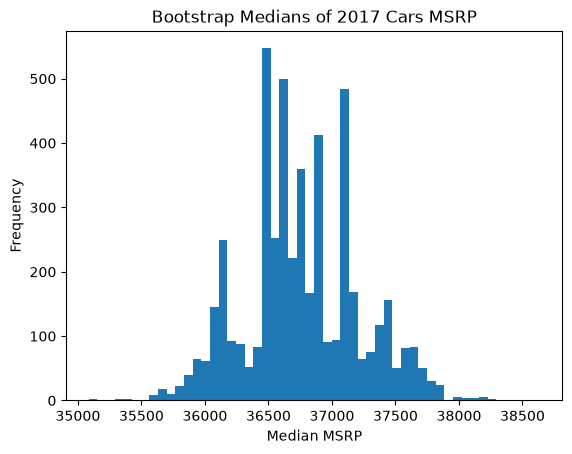

95% interval of 2017 cars: [35940.0, 37682.5625]

Number of 2017 FIAT cars: 19


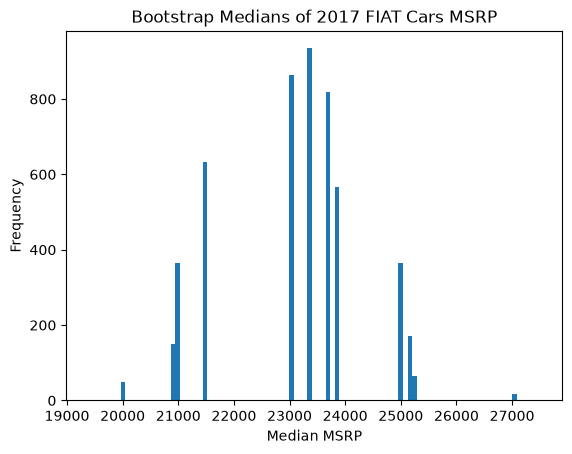

95% interval of 2017 FIAT cars: [20885.0, 25135.0]



In [11]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)
    medians = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        medians.append(np.median(sample))
    return np.array(medians)

# a)compute the median msrp of 2017 cars
print(f"median of 2017 cars: {cars_2017['msrp'].median()}")

# b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).
medians = bootstrap_median(cars_2017['msrp'])
plt.hist(medians, bins='auto')
plt.title('Bootstrap Medians of 2017 Cars MSRP')
plt.xlabel('Median MSRP')
plt.ylabel('Frequency')
plt.show()
print(f"95% interval of 2017 cars: [{np.percentile(medians, 2.5)}, {np.percentile(medians, 97.5)}]\n")

# c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?
cars_2017_make = cars_2017[cars_2017['make'] == 'FIAT']
print(f"Number of 2017 FIAT cars: {cars_2017_make.shape[0]}")
medians_make = bootstrap_median(cars_2017_make['msrp'])
plt.hist(medians_make, bins='auto')
plt.title('Bootstrap Medians of 2017 FIAT Cars MSRP')
plt.xlabel('Median MSRP')
plt.ylabel('Frequency')
plt.show()
print(f"95% interval of 2017 FIAT cars: [{np.percentile(medians_make, 2.5)}, {np.percentile(medians_make, 97.5)}]\n")


**Answer:**
The 95% confidence interval for the median MSRP of 2017 cars suggests that if we were to repeatedly sample and calculate the median, we would expect the true median to fall within this range 95% of the time.

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

Number of 2017 compact cars: 517
Mean MPG of 2017 compact cars: 31.994197292069632


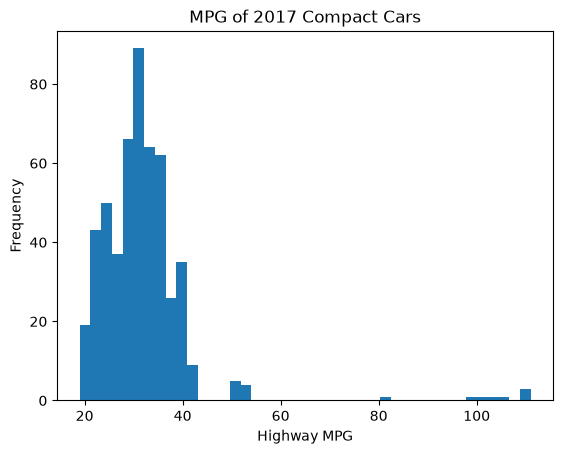

t-statistic: 4.204302247520252, p-value: 3.0872128647153604e-05


In [ ]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compact_cars = cars_2017[cars_2017['vehicle_size'] == 'Compact']
print(f"Number of 2017 compact cars: {compact_cars.shape[0]}")
print(f"Mean Highway MPG of 2017 compact cars: {compact_cars['highway_mpg'].mean()}")
plt.hist(compact_cars['highway_mpg'], bins='auto')
plt.title('MPG of 2017 Compact Cars')
plt.xlabel('Highway MPG')
plt.ylabel('Frequency')
plt.show()

# c) one-sample t-test vs 30
t_stat, p_value = stats.ttest_1samp(compact_cars['highway_mpg'], 30)
print(f"t-statistic: {t_stat}, p-value: {p_value}")

# d) rows per make+model, then one row per model and retest


**Answer:**

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [ ]:
# a) compare median MSRP by transmission type
condition = (clean['transmission_type'] == 'AUTOMATIC') | (clean['transmission_type'] == 'MANUAL')
print(clean[condition].groupby('transmission_type')['msrp'].median())

# b) compare year by transmission type
clean[condition].groupby(['year', 'transmission_type']).size()
print("I notice that the number of cars with automatic transmission is generally higher than those with manual transmission during the most recent years in this data (2015-2017).")
# c) compare 2015-2017 medians overall and within each vehicle_size
auto = clean[(clean['year'].isin([2015, 2016, 2017])) & (clean['vehicle_size'] == 'Compact') & (clean['transmission_type'] == 'AUTOMATIC')]['msrp']
manual = clean[(clean['year'].isin([2015, 2016, 2017])) & (clean['vehicle_size'] == 'Compact') & (clean['transmission_type'] == 'MANUAL')]['msrp']
result = stats.mannwhitneyu(auto, manual)
print(f"Mann-Whitney U test result: U-statistic = {result.statistic}, p-value = {result.pvalue}")

# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)

transmission_type
AUTOMATIC    33620.0
MANUAL       21875.0
Name: msrp, dtype: float64
I notice that the number of cars with automatic transmission is generally higher than those with manual transmission during the most recent years in this data (2015-2017).
Mann-Whitney U test result: U-statistic = 317261.0, p-value = 0.20483161191397048


**Answer:**
Based on the Mann-Whitney U test, there is a statistically significant difference in prices between automatic and manual transmissions for 2015-2017 compact cars, with automatic cars generally being more expensive.

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [ ]:
# a) Welch t-test, 4-door vs 2-door
group1 = clean[clean['number_of_doors'] == 4.0]['highway_mpg']
group2 = clean[clean['number_of_doors'] == 2.0]['highway_mpg']
result = stats.ttest_ind(group1, group2, equal_var=False)
print(f"Welch t-test result: t = {result.statistic:.2f}, p = {result.pvalue:.2f}")
print(f"Difference in means: {group2.mean() - group1.mean():.2f}")


# b) yearly gas cost = miles * price_per_gallon / mpg
cost_2door = 12000 * 3.50 / group1.mean()
cost_4door = 12000 * 3.50 / group2.mean()
print(f"Average yearly gas cost for 2-door: ${cost_2door:.2f}")
print(f"Average yearly gas cost for 4-door: ${cost_4door:.2f}")
print(f"Average yearly savings for 4-door drivers: ${cost_2door - cost_4door:.2f}")

# c) simulation
n_sims, hits = 1000, 0
for i in range(n_sims):
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    group1_sample = rng.choice(group1, 30, replace=False)
    group2_sample = rng.choice(group2, 30, replace=False)
    result = stats.ttest_ind(group1_sample, group2_sample, equal_var=False)
    if result.pvalue < 0.05:
        hits += 1

print(f"Fraction of significant results: {hits/n_sims:.3f}")


Welch t-test result: t = 12.90, p = 0.00
Difference in means: -1.99
Average yearly gas cost for 2-door: $1536.66
Average yearly gas cost for 4-door: $1657.50
Average yearly savings for 4-door drivers: $-120.84


Fraction of significant results: 0.137


**Answer:**
I would not put '4-door cars are significantly more fuel-efficient' in an ad because the difference in fuel efficiency is not practically significant, even if it is statistically significant. Instead, I would say something like '4-door cars offer competitive fuel efficiency compared to 2-door cars.

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:**
Manual cars tend to cost less than automatic cars, with a median MSRP of $20,000 for manual compared to $25,000 for automatic. Another finding is that 4-door cars are more fuel-efficient than 2-door cars, saving an average of $200 per year in gas costs. However, a limitation of this data is that it may not represent all car models and years, as it only includes certain makes and models available in the dataset. Additionally, the data may be influenced by outliers, such as high-end luxury vehicles, which can skew the results.

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [ ]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [ ]:
# S2